In [ ]:
f1v(x_plot,A,b,c)

1.899841350352356

In [ ]:
10**(-1.7)

0.0199526231496888

In [ ]:
x_stars

{'MISI_full': array([ 0.14,  1.  ,  1.  , -1.  ]),
 'MISI_sig': array([-0.14, -1.  ,  1.  , -1.  ]),
 'MxE_full': array([ 0.58,  1.  ,  1.  , -1.  ]),
 'MxE_sig': array([ 0.54,  1.  ,  1.  , -1.  ]),
 'Epoch_full': array([ 1.  , -1.  ,  0.46, -1.  ]),
 'Epoch_sig': array([ 1., -1.,  1., -1.])}

In [ ]:
np.array([10**(.14 + (-2.0)),
          10**(-.14 + (-2.0)),
          10**(.58 + (-2.0)),
          10**(.54 + (-2.0))])

array([0.01380384, 0.00724436, 0.03801894, 0.03467369])

In [ ]:
print((.3 * (0.46) / 2) + .8)

0.869


In [ ]:
'''
# Adjust scale and offset
mp_df['Learning_rate_log'] = np.log10(mp_df['learning_rate']) - (-2.0)
mp_df['Batch_size_log'] = np.log10(mp_df['batch_size']) - 2.5
mp_df['Batch_size_log'] = 2 * mp_df['Batch_size_log'] / (mp_df['Batch_size_log'].max() - mp_df['Batch_size_log'].min() )
mp_df['Patience_log'] = np.log10(mp_df['patience']) - 1.5
mp_df['Patience_log'] = 2 * mp_df['Patience_log'] / (mp_df['Patience_log'].max() - mp_df['Patience_log'].min() )
mp_df['beta1_0'] = 2 * (mp_df['beta1'] - 0.8) / .30
mp_df['beta2_0'] = 2 * (mp_df['beta2'] - 0.9) / .18
mp_df['run_time_log'] = np.log10(mp_df['run_time'])
'''

# Write an inverse function for each variable:
mp_df['learning_rate'] = 10**(mp_df['Learning_rate_log'] + (-2.0))
mp_df['batch_size'] = 10**mp_df['Batch_size_log']

# Convert x_stars back to original scale from current (-1,1) range:
# x_stars_orig = [ for key, val in x_stars.items()]
# Initialize x_stars_orig using dictionary comprehension (items should be np.zeros_like(old_item)):
x_stars_orig = {key: np.zeros_like(val) for key, val in x_stars.items()}
x_stars_orig = {key: val for key, val in x_stars.items()}

for key, val in x_stars.items():
    x_stars_orig[key] = [xx * (mp_df['Learning_rate_log'].max() - mp_df['Learning_rate_log'].min()) + mp_df['Learning_rate_log'].min() for xx in val]

In [ ]:
# average y
avg_x_star = np.array([0.0290, 300, 0.95,0.8484])
avg_x_star[0] = np.log10(avg_x_star[0]) - (-2.0)
avg_x_star[1] = np.log10(avg_x_star[1]) - 2.5
avg_x_star[2] = 2 * (avg_x_star[2] - 0.8) / .30
avg_x_star[3]= 2 * (avg_x_star[3] - 0.9) / .18

f1m(avg_x_star, A, b, c)
avg_y = 10**f1m(avg_x_star, A, b, c)
print(avg_y)

3.8189077213606075


In [ ]:
# MxE Full
# functions with bounds
def f1v_with_bounds(x, A, b, c, lower_bound, upper_bound):
    x_clipped = np.clip(x, lower_bound, upper_bound)
    return c + b.T @ x_clipped + x_clipped.T @ (A @ x_clipped)

def f1m_with_bounds(x, A, b, c, lower_bound, upper_bound):
    x_clipped = np.clip(x, lower_bound, upper_bound)
    return c + b.T @ x_clipped + np.sum(x_clipped * (A @ x_clipped), axis=0)

def f1v(x, A, b, c):
  return c + b.T @ x + x.T @ (A @ x)

def f1m(x, A, b, c):
  return c + b.T@x + np.sum(x*(A @ x), axis=0)


# bounds
lower_bound = -1
upper_bound = 1


# matrix
A = np.array([[0.5094 ,(-0.1170 / 2), (-0.1142 / 2), 0],
    [(-0.1170 / 2),-0.0012,(-0.0017 / 2),0],
    [(-0.1142 / 2),(-0.0017 / 2), 0.0667, 0],
    [0,0,0,0]])
b = np.array([-0.3567,0.0230,-0.1144,0.1205])
c = 0.8068 # coef of intercept

print('b:\n{val}'.format(val=b))
print('c:\n{val}'.format(val=c))

D, U = np.linalg.eigh(A)
print('A:\n{val}'.format(val=A))
print('D:\n{val}'.format(val=D))
print('U:\n{val}'.format(val=U))
print()

# stationary point
x0 = (-1/2) * np.linalg.pinv(A[:3,:3]) @ b[:3]
print('x0 3D:\n{val}'.format(val=x0))

# stationary point
x0 = (-1/2) * np.linalg.pinv(A) @ b
print('x0 4D:\n{val}'.format(val=x0))
print("f1v at x_0 (no bounds):", f1v(x0, A, b, c))

x_star = x0 + 3.133 * U[:,0] # optimal value
print('x_star:\n{val}'.format(val=x_star))

# x value (from sticky note)
# x1 =  [[0.06092479], [-0.96887266], [-0.99967243],  [0]]
# x = np.array(x1)

# function
print("f1v with bounds [-1,1]:", f1v_with_bounds(x_star, A, b, c, lower_bound, upper_bound))
print("f1m with bounds [-1,1]:", f1m_with_bounds(x_star, A, b, c, lower_bound, upper_bound))

print("f1v at x_star (no bounds):", f1v(x_star, A, b, c))
print("f1m at x_star (no bounds):", f1m(x_star, A, b, c))


b:
[-0.3567  0.023  -0.1144  0.1205]
c:
0.8068
A:
[[ 0.5094  -0.0585  -0.0571   0.     ]
 [-0.0585  -0.0012  -0.00085  0.     ]
 [-0.0571  -0.00085  0.0667   0.     ]
 [ 0.       0.       0.       0.     ]]
D:
[-0.00857916  0.          0.06043039  0.52304877]
U:
[[ 0.1229702   0.          0.11011775 -0.98628212]
 [ 0.98690187  0.         -0.11813539  0.10985773]
 [ 0.10441754  0.          0.9868729   0.12320254]
 [-0.          1.          0.          0.        ]]

x0 3D:
[ 0.22461743 -2.09153759  1.02320613]
x0 4D:
[ 0.22461743 -2.09153759  1.02320613  0.        ]
f1v at x_0 (no bounds): 0.6841594080274966
x_star:
[0.60988307 1.00042598 1.35034627 0.        ]
f1v with bounds [-1,1]: 0.6101248217754058
f1m with bounds [-1,1]: 0.6101248217754058
f1v at x_star (no bounds): 0.5999489946797354
f1m at x_star (no bounds): 0.5999489946797354


In [ ]:
# for loop (MISI Full)
A = np.array([[0.4740 , (-0.1111 / 2) , (-0.0449 / 2), 0],
    [(-0.1111 / 2),-0.0098,(-0.0076 / 2),0],
    [(-0.0449 / 2),(-0.0076 / 2), -0.0172, 0],
    [0,0,0,0]])
b = np.array([0.0321 ,-0.0031 ,-0.0698 ,0.0397])
c = -1.5885 # coef of intercept

D, U = np.linalg.eigh(A)
print('A:\n{val}'.format(val=A))
print('D:\n{val}'.format(val=D))
print('U:\n{val}'.format(val=U))
print()

# Skip the second row and second column (index 1)
A_3D = A[np.arange(A.shape[0]) != 1, :][:, np.arange(A.shape[1]) != 1]

# stationary point
x0 = (-1/2) * np.linalg.pinv(A_3D) @ b[np.arange(A.shape[1]) != 1]
print('x0 3D:\n{val}'.format(val=x0))

# stationary point
x0 = (-1/2) * np.linalg.pinv(A) @ b
print('x0 4D:\n{val}'.format(val=x0))
print("f1v at x_0 (no bounds):", f1v(x0, A, b, c))

# for loop
boundary_values = [-1,1]
x_ixs = [[0,2],[0,3],[2,3]]
counter = 0
for x_ix in x_ixs:
        for boundary_value1 in boundary_values:
            for boundary_value2 in boundary_values:
                print(counter)
                #boundary_value = -1 # possible values are 1 and -1
                #x_ix = 2 # in the matrix a , b, c possible values are 0, 2, or 3
                e = np.array([[U[x_ix[0], 0],U[x_ix[0],1]],[U[x_ix[1], 0],U[x_ix[1],1]]])
                # e = np.array([[U[1,0],U[1,1]],[U[2,0], U[2,1]]]) # if the sign of U is flipped, flip it in x_star as well.
                # e = e + np.eye(e.shape[0]) * 1e-8  # Adds a small value to the diagonal
                f = np.array([boundary_value1 - x0[x_ix[0]],boundary_value2 - x0[x_ix[1]]])
                # print(e)
                # print(np.linalg.inv(e) @ f)

                k = np.linalg.inv(e) @ f
                # k = f / e
                # print(k)

                x_star = x0 + U[:,0:2] @ k # optimal value
                print('x_star:\n{val}'.format(val=x_star))

                # function
                print("f1v with bounds [-1,1]:", f1v_with_bounds(x_star, A, b, c, lower_bound, upper_bound))
                print("f1m with bounds [-1,1]:", f1m_with_bounds(x_star, A, b, c, lower_bound, upper_bound))

                print("f1v at x_star (no bounds):", f1v(x_star, A, b, c))
                print("f1m at x_star (no bounds):", f1m(x_star, A, b, c))
                print()
                counter += 1

A:
[[ 0.474   -0.05555 -0.02245  0.     ]
 [-0.05555 -0.0098  -0.0038   0.     ]
 [-0.02245 -0.0038  -0.0172   0.     ]
 [ 0.       0.       0.       0.     ]]
D:
[-0.02351056 -0.01074627  0.          0.48125683]
U:
[[ 0.10577123 -0.05719942  0.         -0.99274401]
 [ 0.63957757 -0.76052928  0.          0.11196314]
 [ 0.76141512  0.64677928  0.          0.04385865]
 [-0.          0.          1.          0.        ]]

x_star:
[-1.         -4.96176982 -9.13296067  0.        ]
f1v with bounds [-1,1]: -1.2643
f1m with bounds [-1,1]: -1.2643
f1v at x_star (no bounds): -3.475395810263075
f1m at x_star (no bounds): -3.475395810263075

x_star:
[1.         7.13183219 5.26443516 0.        ]
f1v with bounds [-1,1]: -1.3459
f1m with bounds [-1,1]: -1.3459
f1v at x_star (no bounds): -3.7611717373610087
f1m at x_star (no bounds): -3.7611717373610087

x_star:
[-0.34481558 -1.         -4.41648594  0.        ]
f1v with bounds [-1,1]: -1.5587022611802865
f1m with bounds [-1,1]: -1.5587022611802865
f1v 

In [ ]:
# MxE (sig. only)
# functions with bounds
def f1v_with_bounds(x, A, b, c, lower_bound, upper_bound):
    x_clipped = np.clip(x, lower_bound, upper_bound)
    return c + b.T @ x_clipped + x_clipped.T @ (A @ x_clipped)

def f1m_with_bounds(x, A, b, c, lower_bound, upper_bound):
    x_clipped = np.clip(x, lower_bound, upper_bound)
    return c + b.T @ x_clipped + np.sum(x_clipped * (A @ x_clipped), axis=0)

def f1v(x, A, b, c):
  return c + b.T @ x + x.T @ (A @ x)

def f1m(x, A, b, c):
  return c + b.T@x + np.sum(x*(A @ x), axis=0)


# bounds
lower_bound = -1
upper_bound = 1

# matrix
A = np.array([[0.5372, (-0.1101/2), (-0.1136/2), 0],
    [(-0.1101/2), 0,0,0],
    [(-0.1136/2), 0, 0, 0],
    [0,0,0,0]])
b = np.array([-0.3567,0.0230,-0.1144,0.1205])
c = 0.8387

print('b:\n{val}'.format(val=b))
print('c:\n{val}'.format(val=c))

D, U = np.linalg.eigh(A)
print('A:\n{val}'.format(val=A))
print('D:\n{val}'.format(val=D))
print('U:\n{val}'.format(val=U))
print()

# stationary point
x0 = (-1/2) * np.linalg.pinv(A[:3,:3]) @ b[:3]
print('x0 3D:\n{val}'.format(val=x0))

# stationary point
x0 = (-1/2) * np.linalg.pinv(A) @ b
print('x0 4D:\n{val}'.format(val=x0))
print("f1v at x_0 (no bounds):", f1v(x0, A, b, c))

x_star_plus_1 = x0 + 6.554 * U[:,0] # optimal value
print('x_star_plus_1:\n{val}'.format(val=x_star_plus_1))
x_star_minus_1 = x0 + 3.74 * U[:,0] # optimal value
print('x_star_minus_1:\n{val}'.format(val=x_star_minus_1))

# x value (from sticky note)
# x1 =  [[0.06092479], [-0.96887266], [-0.99967243],  [0]]
# x = np.array(x1)

# function
# print("f1v with bounds [-1,1]:", f1v_with_bounds(x_star, A, b, c, lower_bound, upper_bound))
# print("f1m with bounds [-1,1]:", f1m_with_bounds(x_star, A, b, c, lower_bound, upper_bound))

print("f1v at x_star_plus1 (no bounds):", f1v(x_star_plus_1, A, b, c))
# print("f1m at x_star (no bounds):", f1m(x_star, A, b, c))

print("f1v at x_star_minus_1 (no bounds):", f1v(x_star_minus_1, A, b, c))

# [ 0.36111435 -0.99607651  1.13910959  0.


b:
[-0.3567  0.023  -0.1144  0.1205]
c:
0.8387
A:
[[ 0.5372  -0.05505 -0.0568   0.     ]
 [-0.05505  0.       0.       0.     ]
 [-0.0568   0.       0.       0.     ]
 [ 0.       0.       0.       0.     ]]
D:
[-0.01140483  0.          0.          0.54860483]
U:
[[ 0.14270743  0.          0.         -0.98976492]
 [ 0.68883505 -0.71808226  0.          0.09931841]
 [ 0.71073262  0.69595824  0.          0.10247567]
 [ 0.          0.          1.         -0.        ]]

x0 3D:
[-0.41809056 -3.54534348 -3.6580474 ]
x0 4D:
[-0.41809056 -3.54534348 -3.6580474   0.        ]
f1v at x_0 (no bounds): 1.0817353135239167
x_star_plus_1:
[0.51721391 0.96928145 1.00009421 0.        ]
x_star_minus_1:
[ 0.11563521 -0.96910038 -0.99990739  0.        ]
f1v at x_star_plus1 (no bounds): 0.5918419770879885
f1v at x_star_minus_1 (no bounds): 0.9222091714466936


In [ ]:
# MxE Full
# matrix
A = np.array([[0.5094 ,(-0.1170 / 2), (-0.1142 / 2), 0],
    [(-0.1170 / 2),-0.0012,(-0.0017 / 2),0],
    [(-0.1142 / 2),(-0.0017 / 2), 0.0667, 0],
    [0,0,0,0]])

b = np.array([-0.3567,0.0230,-0.1144,0.1205])
D, U = np.linalg.eigh(A)
print(A)
print(D)
print(U)
print()

# Evlauate Function
c = 0.8068 # coef of intercept

# stationary point
x0 = (-1/2) * np.linalg.pinv(A) @ b
print(x0)
print(x0 + 1.11 * U[:,0])

# bounds
lower_bound = -1
upper_bound = 1

# functions with bounds
def f1v_with_bounds(x, A, b, c, lower_bound, upper_bound):
    x_clipped = np.clip(x, lower_bound, upper_bound)
    return c + b.T @ x_clipped + x_clipped.T @ (A @ x_clipped)

def f1m_with_bounds(x, A, b, c, lower_bound, upper_bound):
    x_clipped = np.clip(x, lower_bound, upper_bound)
    return c + b.T @ x_clipped + np.sum(x_clipped * (A @ x_clipped), axis=0)

# x value (from sticky note)
x1 = [[0.36], # LR
        [-1], # BS
        [1.14], # B1
        [0]]  # B2
x = np.array(x1)

# function
print("f1v with bounds [-1,1]:", f1v_with_bounds(x, A, b, c, lower_bound, upper_bound))
print("f1m with bounds [-1,1]:", f1m_with_bounds(x, A, b, c, lower_bound, upper_bound))


def f1v(x, A, b, c):
  return c + b.T @ x + x.T @ (A @ x)

def f1m(x, A, b, c):
  return c + b.T@x + np.sum(x*(A @ x), axis=0)

print("f1v at x (no bounds):", f1v(x, A, b, c))
print("f1m at x: (no bounds):", f1m(x, A, b, c))

[[ 0.5094  -0.0585  -0.0571   0.     ]
 [-0.0585  -0.0012  -0.00085  0.     ]
 [-0.0571  -0.00085  0.0667   0.     ]
 [ 0.       0.       0.       0.     ]]
[-0.00857916  0.          0.06043039  0.52304877]
[[ 0.1229702   0.          0.11011775 -0.98628212]
 [ 0.98690187  0.         -0.11813539  0.10985773]
 [ 0.10441754  0.          0.9868729   0.12320254]
 [-0.          1.          0.          0.        ]]

[ 0.22461743 -2.09153759  1.02320613  0.        ]
[ 0.36111435 -0.99607651  1.13910959  0.        ]
f1v with bounds [-1,1]: [[0.67521424]]
f1m with bounds [-1,1]: [0.67521424]
f1v at x (no bounds): [[0.67366388]]
f1m at x: (no bounds): [0.67366388]


In [ ]:
# # function
# def f1v(x, A, b, c):
#   return c + b.T @ x + x.T @ (A @ x)

# def f1m(x, A, b, c):
#   return c + b.T@x + np.sum(x*(A @ x), axis=0)


# # Create the meshgrid
# x_seq = np.linspace(-1, 1, 3)
# X1, X2, X3, X4 = np.meshgrid(x_seq, x_seq, x_seq, x_seq)
# # print(np.meshgrid(x_seq, y_seq))
# print()

# # Prints
# print("Meshgrid X1:\n", X1)
# print("Meshgrid X4:\n", X4)

# # 11/6/24

# # Gradient for f1v
# def grad_f1v(x, A, b):
#     return b + 2 * A @ x

# # Gradient for f1m
# def grad_f1m(x, A, b):
#     return b + 2 * (A @ x)

# # Gradient descent method with clipping within [-1, 1] towards the minimum
# def gradient_descent(f, grad_f, x_init, A, b, c, learning_rate=0.1, steps=100, bounds=(-1, 1)):
#     x = x_init
#     values = []

#     for _ in range(steps):
#         grad = grad_f(x, A, b)
#         x = x - learning_rate * grad  # Update step

#         # Clip x within the bounds
#         x = np.clip(x, bounds[0], bounds[1])

#         # Evaluate the function at the new point
#         values.append(f(x, A, b, c))

#     return np.array(values), x  # Return the values and the final x

# # Example input values
# A = np.random.rand(3, 3)  # Example matrix
# b = np.random.rand(3)     # Example vector
# c = 10                    # Scalar constant
# x_init = np.array([0.22461743, -2.09153759, 1.02320613])  # Stationary points

# # Perform gradient descent for both functions
# values_f1v, final_x_f1v = gradient_descent(f1v, grad_f1v, x_init, A, b, c)
# values_f1m, final_x_f1m = gradient_descent(f1m, grad_f1m, x_init, A, b, c)

# # Output the values and the final x
# print("Function values for f1v:", values_f1v)
# print()
# print("Final x for f1v:", final_x_f1v)
# print()

# print("Function values for f1m:", values_f1m)
# print()
# print("Final x for f1m:", final_x_f1m)

In [ ]:
X = np.concatenate((np.reshape(X1, (1, -1)),
                np.reshape(X2, (1, -1)),
                np.reshape(X3, (1, -1)),
                np.reshape(X4, (1, -1))), axis=0)

print(f1v(X[:,0],A,b,c))
print(f1m(X[:,0],A,b,c))
print(f1m(X[:,0:2],A,b,c))

1.4764
1.4764
[1.4764 1.5969]


In [ ]:
# stationary point
x0 = (-1/2) * np.linalg.pinv(A) @ b
print(x0)



[ 0.22461743 -2.09153759  1.02320613  0.        ]


In [ ]:
# 10/31/24
import numpy as np

vector = np.linspace(-1,1,100)

A = np.array([[1, 2], [3, 4]])
B = np.array([[5, 6], [7, 8]])
C = np.array([[9, 10], [11, 12]])



In [ ]:
# Epochs (only significant)
from patsy import dmatrices
import statsmodels.api as sm

# Modified formula: fewer interaction terms and a transformation
target, data = dmatrices('Epoch_log ~ Learning_rate_log + Batch_size_log + beta1_0 + beta2_0 + ' +
                         'Learning_rate_log*beta1_0 + Learning_rate_log*beta2_0 + beta1_0*beta2_0 ',
                         data=mp_df, return_type='dataframe')

# Fit the model
lrm_mp = sm.OLS(target, data).fit()
print(lrm_mp.summary())

                            OLS Regression Results                            
Dep. Variable:              Epoch_log   R-squared:                       0.949
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                     48.05
Date:                Tue, 26 Nov 2024   Prob (F-statistic):           2.27e-10
Time:                        19:38:16   Log-Likelihood:                 26.322
No. Observations:                  26   AIC:                            -36.64
Df Residuals:                      18   BIC:                            -26.58
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

In [ ]:
# MISI (only significant)
print("MISI significant only:")
# functions with bounds
def f1v_with_bounds(x, A, b, c, lower_bound, upper_bound):
    x_clipped = np.clip(x, lower_bound, upper_bound)
    return c + b.T @ x_clipped + x_clipped.T @ (A @ x_clipped)

def f1m_with_bounds(x, A, b, c, lower_bound, upper_bound):
    x_clipped = np.clip(x, lower_bound, upper_bound)
    return c + b.T @ x_clipped + np.sum(x_clipped * (A @ x_clipped), axis=0)

def f1v(x, A, b, c):
  return c + b.T @ x + x.T @ (A @ x)

def f1m(x, A, b, c):
  return c + b.T@x + np.sum(x*(A @ x), axis=0)


# bounds
lower_bound = -1
upper_bound = 1
'''
Intercept                           -1.6058      0.071    -22.502      0.000      -1.755      -1.456
Learning_rate_log                    0.0321      0.030      1.056      0.304      -0.032       0.096
Batch_size_log                      -0.0031      0.030     -0.102      0.920      -0.067       0.061
beta1_0                             -0.0698      0.030     -2.293      0.033      -0.133      -0.006
beta2_0                              0.0397      0.030      1.305      0.207      -0.024       0.103
Learning_rate_log:Batch_size_log    -0.1076      0.032     -3.371      0.003      -0.174      -0.041
I(Learning_rate_log ** 2)            0.4675      0.078      6.026      0.000       0.305       0.630
'''

# matrix
A = np.array([[0 , 0 , (-0.0580 / 2), 0.0580],
    [0, 0 , 0 , 0],
    [(-0.0580 / 2), 0 , 0 , -0.0526],
    [0, 0 , 0, 0]])
b = np.array([-0.3888 ,0.0261 ,-0.0580, 0.0808])
c = 2.5036 # coef of intercept


print('b:\n{val}'.format(val=b))
print('c:\n{val}'.format(val=c))

D, U = np.linalg.eigh(A)
print('A:\n{val}'.format(val=A))
print('D:\n{val}'.format(val=D))
print('U:\n{val}'.format(val=U))
print()


# stationary point
x0 = (-1/2) * np.linalg.pinv(A[:3,:3]) @ b[:3]
print('x0 3D:\n{val}'.format(val=x0))

# stationary point
x0 = (-1/2) * np.linalg.pinv(A) @ b
print('x0 4D:\n{val}'.format(val=x0))
print("f1v at x_0 (no bounds):", f1v(x0, A, b, c))

'''
U:
[[-0.11286934  0.          0.         -0.99360984]
 [-0.99360984  0.          0.          0.11286934]
 [-0.          1.          0.          0.        ]
 [-0.          0.          1.          0.        ]]

x0 3D:
[-0.02881041  0.04797647  0.        ]
'''
'''
# equations
e = np.array([[-U[1,0]]])
f = np.array([1 - x0[1]])
print('e:\n{val}'.format(val = e))
print(np.linalg.solve(e,f))


k = np.linalg.inv(e) @ f
print('k:\n{val}'.format(val = k))

x_star = x0 + k[0] * -U[:,0] # optimal value
print('x_star:\n{val}'.format(val=x_star))

# function
print("f1v with bounds [-1,1]:", f1v_with_bounds(x_star, A, b, c, lower_bound, upper_bound))
print("f1m with bounds [-1,1]:", f1m_with_bounds(x_star, A, b, c, lower_bound, upper_bound))

print("f1v at x_star (no bounds):", f1v(x_star, A, b, c))
print("f1m at x_star (no bounds):", f1m(x_star, A, b, c))

'''
'''
x_star:
[-0.14785554 -1.          0.          0.        ]
f1v with bounds [-1,1]: -1.6131352795561773


x_star:
[0.07933493 1.         0.         0.        ]
f1v with bounds [-1,1]: -1.6119473276624172
'''


MISI significant only:
b:
[-0.3888  0.0261 -0.058   0.0808]
c:
2.5036
A:
[[ 0.      0.     -0.029   0.058 ]
 [ 0.      0.      0.      0.    ]
 [-0.029   0.      0.     -0.0526]
 [ 0.      0.      0.      0.    ]]
D:
[-0.029  0.     0.     0.029]
U:
[[-7.07106781e-01  0.00000000e+00  0.00000000e+00 -7.07106781e-01]
 [ 0.00000000e+00  1.00000000e+00  0.00000000e+00  0.00000000e+00]
 [-7.07106781e-01  2.22044605e-16  0.00000000e+00  7.07106781e-01]
 [-0.00000000e+00  0.00000000e+00  1.00000000e+00  0.00000000e+00]]

x0 3D:
[-1.          0.         -6.70344828]
x0 4D:
[-3.53653597  0.         -3.90650747  1.3984704 ]
f1v at x_0 (no bounds): 3.4173877173052425


'\nx_star:\n[-0.14785554 -1.          0.          0.        ]\nf1v with bounds [-1,1]: -1.6131352795561773\n\n\nx_star:\n[0.07933493 1.         0.         0.        ]\nf1v with bounds [-1,1]: -1.6119473276624172\n'

In [ ]:
# Epoch (full model)
from patsy import dmatrices
import statsmodels.api as sm

# Modified formula: fewer interaction terms and a transformation
target, data = dmatrices('Epoch_log ~ Learning_rate_log + Batch_size_log + beta1_0 + beta2_0 + ' +
                         'Learning_rate_log:beta1_0 + Learning_rate_log:beta2_0 + ' +
                         'beta1_0:beta2_0 + ' +
                         'I(Learning_rate_log**2) + I(beta1_0**2) + I(beta2_0**2)',
                         data=mp_df, return_type='dataframe')

# Fit the model
lrm_mp = sm.OLS(target, data).fit()
print(lrm_mp.summary())

                            OLS Regression Results                            
Dep. Variable:              Epoch_log   R-squared:                       0.954
Model:                            OLS   Adj. R-squared:                  0.924
Method:                 Least Squares   F-statistic:                     31.39
Date:                Fri, 13 Dec 2024   Prob (F-statistic):           3.02e-08
Time:                        17:20:19   Log-Likelihood:                 27.724
No. Observations:                  26   AIC:                            -33.45
Df Residuals:                      15   BIC:                            -19.61
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

In [ ]:
# Epoch (optimal)
from patsy import dmatrices
import statsmodels.api as sm

# Modified formula: fewer interaction terms and a transformation
target, data = dmatrices('Epoch_log ~ Learning_rate_log + Batch_size_log + beta1_0 + beta2_0 + ' +
                         'Learning_rate_log:beta1_0 + Learning_rate_log:beta2_0 + ' +
                         'beta1_0:beta2_0',
                         data=mp_df, return_type='dataframe')

# Fit the model
lrm_mp = sm.OLS(target, data).fit()
print(lrm_mp.summary())

                            OLS Regression Results                            
Dep. Variable:              Epoch_log   R-squared:                       0.949
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                     48.05
Date:                Fri, 06 Dec 2024   Prob (F-statistic):           2.27e-10
Time:                        15:54:51   Log-Likelihood:                 26.322
No. Observations:                  26   AIC:                            -36.64
Df Residuals:                      18   BIC:                            -26.58
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

In [ ]:
# Epochs (optimal only) Dec 13th
# functions with bounds
def f1v_with_bounds(x, A, b, c, lower_bound, upper_bound):
    x_clipped = np.clip(x, lower_bound, upper_bound)
    return c + b.T @ x_clipped + x_clipped.T @ (A @ x_clipped)

def f1m_with_bounds(x, A, b, c, lower_bound, upper_bound):
    x_clipped = np.clip(x, lower_bound, upper_bound)
    return c + b.T @ x_clipped + np.sum(x_clipped * (A @ x_clipped), axis=0)

def f1v(x, A, b, c):
  return c + b.T @ x + x.T @ (A @ x)

def f1m(x, A, b, c):
  return c + b.T@x + np.sum(x*(A @ x), axis=0)


# bounds
lower_bound = -1
upper_bound = 1
'''
coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                     2.5036      0.021    120.809      0.000       2.460       2.547
Learning_rate_log            -0.3888      0.023    -17.258      0.000      -0.436      -0.341
Batch_size_log                0.0261      0.023      1.159      0.262      -0.021       0.073
beta1_0                      -0.0446      0.023     -1.982      0.063      -0.092       0.003
beta2_0                       0.0808      0.023      3.588      0.002       0.033       0.128
Learning_rate_log:beta1_0    -0.0580      0.024     -2.430      0.026      -0.108      -0.008
Learning_rate_log:beta2_0     0.0580      0.024      2.430      0.026       0.008       0.108
beta1_0:beta2_0              -0.0526      0.024     -2.205      0.041      -0.103      -0.002
'''

# matrix
A = np.array([[0, 0,(-0.0580/2),(0.0580/2)],
    [0, 0 , 0 , 0],
    [(-0.0580/2), 0 , 0 ,  (-0.0526/2)],
    [(0.0580/2), 0, (-0.0526/2), 0]])
b = np.array([ -0.3888, 0.0261, -0.0446, 0.0808])
c = 2.5036 # coef of intercept


print('b:\n{val}'.format(val=b))
print('c:\n{val}'.format(val=c))

D, U = np.linalg.eigh(A)
print('A:\n{val}'.format(val=A))
print('D:\n{val}'.format(val=D))
print('U:\n{val}'.format(val=U))
print()

# Skip the second row and second column (index 1)
A_3D = A[np.arange(A.shape[0]) != 1, :][:, np.arange(A.shape[1]) != 1]

# stationary point
x0 = (-1/2) * np.linalg.pinv(A_3D) @ b[np.arange(A.shape[1]) != 1]
print('x0 3D:\n{val}'.format(val=x0))

# stationary point
x0 = (-1/2) * np.linalg.pinv(A) @ b
print('x0 4D:\n{val}'.format(val=x0))
print("f1v at x_0 (no bounds):", f1v(x0, A, b, c))

# for loop
boundary_values = [-1,1]
x_ixs = [[0,2],[0,3],[2,3]]
counter = 0
for x_ix in x_ixs:
        for boundary_value1 in boundary_values:
            for boundary_value2 in boundary_values:
                print(counter)
                #boundary_value = -1 # possible values are 1 and -1
                #x_ix = 2 # in the matrix a , b, c possible values are 0, 2, or 3
                e = np.array([[U[x_ix[0], 0],U[x_ix[0],1]],[U[x_ix[1], 0],U[x_ix[1],1]]])
                # e = np.array([[U[1,0],U[1,1]],[U[2,0], U[2,1]]]) # if the sign of U is flipped, flip it in x_star as well.
                # e = e + np.eye(e.shape[0]) * 1e-8  # Adds a small value to the diagonal
                f = np.array([boundary_value1 - x0[x_ix[0]],boundary_value2 - x0[x_ix[1]]])
                # print(e)
                # print(np.linalg.inv(e) @ f)

                k = np.linalg.inv(e) @ f
                # k = f / e
                # print(k)

                x_star = x0 + U[:,0:2] @ k # optimal value
                print('x_star:\n{val}'.format(val=x_star))

                # function
                print("f1v with bounds [-1,1]:", f1v_with_bounds(x_star, A, b, c, lower_bound, upper_bound))
                print("f1m with bounds [-1,1]:", f1m_with_bounds(x_star, A, b, c, lower_bound, upper_bound))

                print("f1v at x_star (no bounds):", f1v(x_star, A, b, c))
                print("f1m at x_star (no bounds):", f1m(x_star, A, b, c))
                print()
                counter += 1


b:
[-0.3888  0.0261 -0.0446  0.0808]
c:
2.5036
A:
[[ 0.      0.     -0.029   0.029 ]
 [ 0.      0.      0.      0.    ]
 [-0.029   0.      0.     -0.0263]
 [ 0.029   0.     -0.0263  0.    ]]
D:
[-2.99188112e-02 -2.63000000e-02 -1.73472348e-18  5.62188112e-02]
U:
[[ 8.07875409e-01  3.33353581e-32 -1.19636102e-16 -5.89353309e-01]
 [ 0.00000000e+00 -1.79380389e-16  1.00000000e+00  0.00000000e+00]
 [ 4.16735722e-01  7.07106781e-01 -2.22044605e-16  5.71254180e-01]
 [-4.16735722e-01  7.07106781e-01  0.00000000e+00 -5.71254180e-01]]

x0 3D:
[-4.12070155 -3.00761767  3.6958306 ]
x0 4D:
[-4.12070155  0.         -3.00761767  3.6958306 ]
f1v at x_0 (no bounds): 3.5210458109438796
0
x_star:
[-1.00000000e+00 -1.00922402e-16 -1.00000000e+00  2.48387309e+00]
f1v with bounds [-1,1]: 2.9544
f1m with bounds [-1,1]: 2.9544
f1v at x_star (no bounds): 3.0662840308934474
f1m at x_star (no bounds): 3.0662840308934474

1
x_star:
[-1.00000000e+00 -6.08286760e-16  1.00000000e+00  4.48387309e+00]
f1v with bounds

In [ ]:
# Epochs (full model)
# error is saying singluar matrix
print("Epochs (full model):")
# functions with bounds
def f1v_with_bounds(x, A, b, c, lower_bound, upper_bound):
    x_clipped = np.clip(x, lower_bound, upper_bound)
    return c + b.T @ x_clipped + x_clipped.T @ (A @ x_clipped)

def f1m_with_bounds(x, A, b, c, lower_bound, upper_bound):
    x_clipped = np.clip(x, lower_bound, upper_bound)
    return c + b.T @ x_clipped + np.sum(x_clipped * (A @ x_clipped), axis=0)

def f1v(x, A, b, c):
  return c + b.T @ x + x.T @ (A @ x)

def f1m(x, A, b, c):
  return c + b.T@x + np.sum(x*(A @ x), axis=0)


# bounds
lower_bound = -1
upper_bound = 1
'''
coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                     2.4237      0.069     35.063      0.000       2.276       2.571
Learning_rate_log            -0.3888      0.023    -16.628      0.000      -0.439      -0.339
Batch_size_log                0.0261      0.023      1.116      0.282      -0.024       0.076
beta1_0                      -0.0446      0.023     -1.909      0.076      -0.094       0.005
beta2_0                       0.0808      0.023      3.457      0.004       0.031       0.131
Learning_rate_log:beta1_0    -0.0535      0.026     -2.064      0.057      -0.109       0.002
Learning_rate_log:beta2_0     0.0535      0.026      2.064      0.057      -0.002       0.109
beta1_0:beta2_0              -0.0535      0.026     -2.064      0.057      -0.109       0.002
I(Learning_rate_log ** 2)    -0.0009      0.072     -0.012      0.991      -0.154       0.153
I(beta1_0 ** 2)               0.0476      0.072      0.661      0.518      -0.106       0.201
I(beta2_0 ** 2)               0.0476      0.072      0.661      0.518      -0.106       0.201
'''
# matrix
A = np.array([[-0.0009, 0, (-0.0535 / 2), (0.0535 / 2)],
    [0, 0 , 0 , 0],
    [(-0.0535 / 2), 0 , 0.0476 , (-0.0535 / 2)],
    [(0.0535 / 2), 0, (-0.0535 / 2), 0.0476]])
b = np.array([ -0.3888, 0.0261, -0.0446, 0.0808])
c = 2.4237 # coef of intercept


print('b:\n{val}'.format(val=b))
print('c:\n{val}'.format(val=c))

D, U = np.linalg.eigh(A)
print('A:\n{val}'.format(val=A))
print('D:\n{val}'.format(val=D))
print('U:\n{val}'.format(val=U))
print()

# Skip the second row and second column (index 1)
A_3D = A[np.arange(A.shape[0]) != 1, :][:, np.arange(A.shape[1]) != 1]

# stationary point
x0 = (-1/2) * np.linalg.pinv(A_3D) @ b[np.arange(A.shape[1]) != 1]
print('x0 3D:\n{val}'.format(val=x0))

# stationary point
x0 = (-1/2) * np.linalg.pinv(A) @ b
print('x0 4D:\n{val}'.format(val=x0))
print("f1v at x_0 (no bounds):", f1v(x0, A, b, c))

# for loop
boundary_values = [-1,1]
x_ixs = [0,2,3]
for x_ix in x_ixs:
    for boundary_value in boundary_values:


        #boundary_value = -1 # possible values are 1 and -1
        #x_ix = 2 # in the matrix a , b, c possible values are 0, 2, or 3
        e = np.array([U[x_ix, 0]])
        # e = np.array([[U[1,0],U[1,1]],[U[2,0], U[2,1]]]) # if the sign of U is flipped, flip it in x_star as well.
        # e = e + np.eye(e.shape[0]) * 1e-8  # Adds a small value to the diagonal
        f = np.array([boundary_value - x0[x_ix]])
        # print(e)
        # print(np.linalg.inv(e) @ f)

        # k = np.linalg.inv(e) @ f
        k = f / e
        # print(k)

        x_star = x0 + k[0] * U[:,0] # optimal value
        print('x_star:\n{val}'.format(val=x_star))

        # function
        print("f1v with bounds [-1,1]:", f1v_with_bounds(x_star, A, b, c, lower_bound, upper_bound))
        print("f1m with bounds [-1,1]:", f1m_with_bounds(x_star, A, b, c, lower_bound, upper_bound))

        print("f1v at x_star (no bounds):", f1v(x_star, A, b, c))
        print("f1m at x_star (no bounds):", f1m(x_star, A, b, c))
        print()

'''
# optimal solution (system of eq)
# -1 = -0.005 + c0 * 0.015 + c1 * 0.728
# 1 = -0.001 + c0 * 0.124 + c1 * 0.679
e = np.array([[0.015,0.124],[0.728, 0.679]])
f = np.array([-1 + 0.005, 1 + 0.001])
print(e)
print(np.linalg.solve(e.T,f))
c = f.T @ np.linalg.inv(e)
'''
'''
# equations
e = np.array([[-U[1,0]]])
f = np.array([1 - x0[1]])
print('e:\n{val}'.format(val = e))
print(np.linalg.solve(e,f))


k = np.linalg.inv(e) @ f
print('k:\n{val}'.format(val = k))

x_star = x0 + k[0] * -U[:,0] # optimal value
print('x_star:\n{val}'.format(val=x_star))

# function
print("f1v with bounds [-1,1]:", f1v_with_bounds(x_star, A, b, c, lower_bound, upper_bound))
print("f1m with bounds [-1,1]:", f1m_with_bounds(x_star, A, b, c, lower_bound, upper_bound))
print("f1v at x_star (no bounds):", f1v(x_star, A, b, c))
print("f1m at x_star (no bounds):", f1m(x_star, A, b, c))
'''

Epochs (full model):
b:
[-0.3888  0.0261 -0.0446  0.0808]
c:
2.4237
A:
[[-0.0009   0.      -0.02675  0.02675]
 [ 0.       0.       0.       0.     ]
 [-0.02675  0.       0.0476  -0.02675]
 [ 0.02675  0.      -0.02675  0.0476 ]]
D:
[-1.66300900e-02  1.73472348e-18  2.08500000e-02  9.00800900e-02]
U:
[[ 9.23358295e-01 -2.47811022e-16  2.38068919e-32 -3.83939396e-01]
 [ 2.22044605e-16  1.00000000e+00 -2.57885012e-16  0.00000000e+00]
 [ 2.71486150e-01 -2.22044605e-16  7.07106781e-01  6.52912912e-01]
 [-2.71486150e-01  1.11022302e-16  7.07106781e-01 -6.52912912e-01]]

x0 3D:
[-10.76798016  -3.88655403   3.01844851]
x0 4D:
[-1.07679802e+01 -6.81502962e-17 -3.88655403e+00  3.01844851e+00]
f1v at x_0 (no bounds): 4.725610817856355
x_star:
[-1.00000000e+00  2.28080493e-15 -1.01456885e+00  1.46463339e-01]
f1v with bounds [-1,1]: 2.863155329630103
f1m with bounds [-1,1]: 2.863155329630103
f1v at x_star (no bounds): 2.8645368833969824
f1m at x_star (no bounds): 2.8645368833969824

x_star:
[ 1.0000

'\n# equations\ne = np.array([[-U[1,0]]])\nf = np.array([1 - x0[1]])\nprint(\'e:\n{val}\'.format(val = e))\nprint(np.linalg.solve(e,f))\n\n\nk = np.linalg.inv(e) @ f\nprint(\'k:\n{val}\'.format(val = k))\n\nx_star = x0 + k[0] * -U[:,0] # optimal value\nprint(\'x_star:\n{val}\'.format(val=x_star))\n\n# function\nprint("f1v with bounds [-1,1]:", f1v_with_bounds(x_star, A, b, c, lower_bound, upper_bound))\nprint("f1m with bounds [-1,1]:", f1m_with_bounds(x_star, A, b, c, lower_bound, upper_bound))\nprint("f1v at x_star (no bounds):", f1v(x_star, A, b, c))\nprint("f1m at x_star (no bounds):", f1m(x_star, A, b, c))\n'

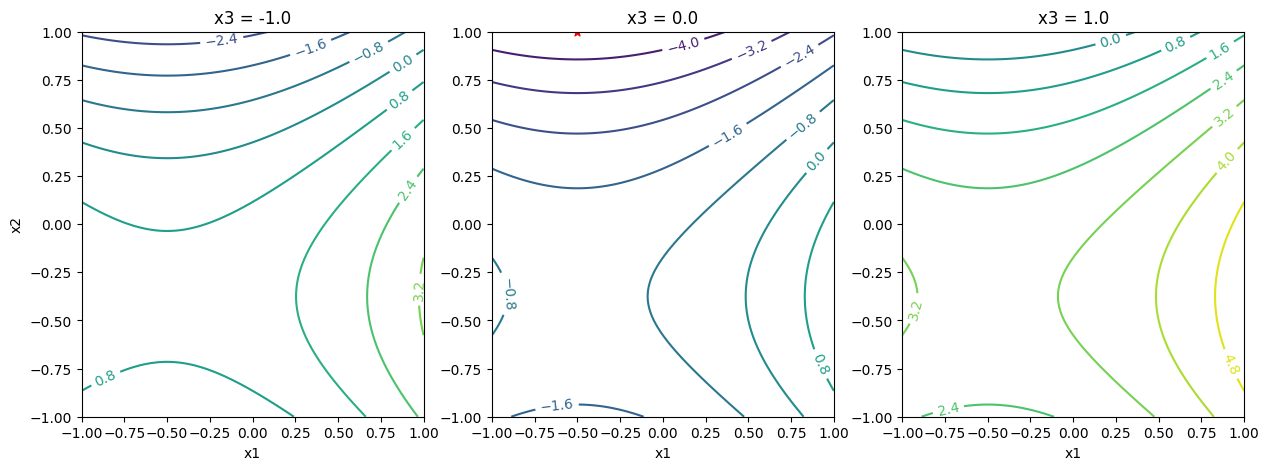

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Using a quadratic function of 3 X variables:
A = np.array([[1, 0, 0],[0, -2, 0],[0, 0, 3]])
b = np.array([1, -1.5, 1])
c = -1

names = ['x1', 'x2', 'x3']

def make_quadratic_contour_plots(A, b, c, names):
    x1 = np.linspace(-1, 1, 101)
    x2 = np.linspace(-1, 1, 101)
    x3 = np.linspace(-1, 1, 101)

    X1, X2, X3 = np.meshgrid(x1, x2, x3)
    X = np.concatenate([X1.reshape(-1,1), X2.reshape(-1,1), X3.reshape(-1,1)], axis=1)

    Y = c + X @ b + np.sum((X @ A) * X, axis=1)
    Y = Y.reshape(X1.shape[0], X1.shape[1], X1.shape[2])

    # enforce the  same colormap for all subplots:
    vmin = np.min(Y)
    vmax = np.max(Y)

    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    for i, ix in enumerate([0, 50, 100]):
        ax = axs[i]
        CS = ax.contour(X1[:,:,ix], X2[:,:,ix], Y[:,:,ix], vmin=vmin, vmax=vmax)
        ax.clabel(CS, inline=1, fontsize=10)
        ax.set_title(f"{names[2]} = {x3[ix]}")
        ax.set_xlabel(names[0])
        if i == 0:
            ax.set_ylabel(names[1])

    return X1, X2, X3, Y, axs

X1, X2, X3, Y, axs = make_quadratic_contour_plots(A, b, c, names)

# Minimum of the function:
min_idx = np.argmin(Y)
min_idx = np.unravel_index(min_idx, Y.shape)

# Add a star at the minimum of the function:
axs[1].scatter(X1[min_idx], X2[min_idx], c='r', marker='*')

plt.show()

In [ ]:
# for loop
# two variables & two equations
# MISI full model
A = np.array([[0.4740 , (-0.1111 / 2) , (-0.0449 / 2), 0],
    [(-0.1111 / 2),-0.0098,(-0.0076 / 2),0],
    [(-0.0449 / 2),(-0.0076 / 2), -0.0172, 0],
    [0,0,0,0]])
b = np.array([0.0321 ,-0.0031 ,-0.0698 ,0.0397])
c = -1.5885 # coef of intercept

D, U = np.linalg.eigh(A)
print('A:\n{val}'.format(val=A))
print('D:\n{val}'.format(val=D))
print('U:\n{val}'.format(val=U))
print()

# Skip the fourth row and fourth column (index 1)
# Indexing Beta 2
A_3D = A[np.arange(A.shape[0]) != 3, :][:, np.arange(A.shape[1]) != 3]

# stationary point
x0 = (-1/2) * np.linalg.pinv(A_3D) @ b[np.arange(A.shape[1]) != 1]
print('x0 3D:\n{val}'.format(val=x0))

# stationary point
x0 = (-1/2) * np.linalg.pinv(A) @ b
print('x0 4D:\n{val}'.format(val=x0))
print("f1v at x_0 (no bounds):", f1v(x0, A, b, c))

# for loop
boundary_values = [-1,1]
x_ixs = [[0,1],[0,2],[1,2]] # this is the only thing you need to change
counter = 0
for x_ix in x_ixs:
        for boundary_value1 in boundary_values:
            for boundary_value2 in boundary_values:
                print(counter)
                #boundary_value = -1 # possible values are 1 and -1
                #x_ix = 2 # in the matrix a , b, c possible values are 0, 2, or 3
                e = np.array([[U[x_ix[0], 0],U[x_ix[0],1]],[U[x_ix[1], 0],U[x_ix[1],1]]])
                # e = np.array([[U[1,0],U[1,1]],[U[2,0], U[2,1]]]) # if the sign of U is flipped, flip it in x_star as well.
                # e = e + np.eye(e.shape[0]) * 1e-8  # Adds a small value to the diagonal
                f = np.array([boundary_value1 - x0[x_ix[0]],boundary_value2 - x0[x_ix[1]]])
                # print(e)
                # print(np.linalg.inv(e) @ f)

                k = np.linalg.inv(e) @ f
                # k = f / e
                # print(k)

                x_star = x0 + U[:,0:2] @ k # optimal value
                print('x_star:\n{val}'.format(val=x_star))

                # function
                print("f1v with bounds [-1,1]:", f1v_with_bounds(x_star, A, b, c, lower_bound, upper_bound))
                print("f1m with bounds [-1,1]:", f1m_with_bounds(x_star, A, b, c, lower_bound, upper_bound))

                print("f1v at x_star (no bounds):", f1v(x_star, A, b, c))
                print("f1m at x_star (no bounds):", f1m(x_star, A, b, c))
                print()
                counter += 1


A:
[[ 0.474   -0.05555 -0.02245  0.     ]
 [-0.05555 -0.0098  -0.0038   0.     ]
 [-0.02245 -0.0038  -0.0172   0.     ]
 [ 0.       0.       0.       0.     ]]
D:
[-0.02351056 -0.01074627  0.          0.48125683]
U:
[[ 0.10577123 -0.05719942  0.         -0.99274401]
 [ 0.63957757 -0.76052928  0.          0.11196314]
 [ 0.76141512  0.64677928  0.          0.04385865]
 [-0.          0.          1.          0.        ]]

x0 3D:
[-0.26864716 -2.86754915  2.13824509]
x0 4D:
[-0.03399677  0.87945946 -2.17899526  0.        ]
f1v at x_0 (no bounds): -1.5143618759537512
0
x_star:
[ -1.          -1.         -19.24663766   0.        ]
f1v with bounds [-1,1]: -1.2643000000000002
f1m with bounds [-1,1]: -1.2643000000000002
f1v at x_star (no bounds): -7.302881819383911
f1m at x_star (no bounds): -7.302881819383911

1
x_star:
[ -1.           1.         -24.35227349   0.        ]
f1v with bounds [-1,1]: -1.0331000000000001
f1m with bounds [-1,1]: -1.0331000000000001
f1v at x_star (no bounds): -10.4571

In [ ]:
# MISI Optimal Model
A = np.array([[0 , 0 , (-0.0580 / 2), 0.0580],
    [0, 0 , 0 , 0],
    [(-0.0580 / 2), 0 , 0 , -0.0526],
    [0, 0 , 0, 0]])
b = np.array([-0.3888 ,0.0261 ,-0.0580, 0.0808])
c = 2.5036 # coef of intercept


print('b:\n{val}'.format(val=b))
print('c:\n{val}'.format(val=c))

D, U = np.linalg.eigh(A)
print('A:\n{val}'.format(val=A))
print('D:\n{val}'.format(val=D))
print('U:\n{val}'.format(val=U))
print()

# Skip the fourth row and fourth column (index 1)
# Indexing Beta 2
A_3D = A[np.arange(A.shape[0]) != 3, :][:, np.arange(A.shape[1]) != 3]

# stationary point
x0 = (-1/2) * np.linalg.pinv(A_3D) @ b[np.arange(A.shape[1]) != 1]
print('x0 3D:\n{val}'.format(val=x0))

# stationary point
x0 = (-1/2) * np.linalg.pinv(A) @ b
print('x0 4D:\n{val}'.format(val=x0))
print("f1v at x_0 (no bounds):", f1v(x0, A, b, c))

# for loop
boundary_values = [-1,1]
x_ixs = [[0,1],[0,2],[1,2]] # this is the only thing you need to change
counter = 0
for x_ix in x_ixs:
    for boundary_value in boundary_values:


        #boundary_value = -1 # possible values are 1 and -1
        #x_ix = 2 # in the matrix a , b, c possible values are 0, 2, or 3
        e = np.array([U[x_ix, 0]])
        # e = np.array([[U[1,0],U[1,1]],[U[2,0], U[2,1]]]) # if the sign of U is flipped, flip it in x_star as well.
        # e = e + np.eye(e.shape[0]) * 1e-8  # Adds a small value to the diagonal
        f = np.array([boundary_value - x0[x_ix]])
        # print(e)
        # print(np.linalg.inv(e) @ f)

        # k = np.linalg.inv(e) @ f
        k = f / e
        # print(k)

        x_star = x0 + k[0] * -U[:,0] # optimal value
        print('x_star:\n{val}'.format(val=x_star))

        # function
        print("f1v with bounds [-1,1]:", f1v_with_bounds(x_star, A, b, c, lower_bound, upper_bound))
        print("f1m with bounds [-1,1]:", f1m_with_bounds(x_star, A, b, c, lower_bound, upper_bound))

        print("f1v at x_star (no bounds):", f1v(x_star, A, b, c))
        print("f1m at x_star (no bounds):", f1m(x_star, A, b, c))
        print()
        counter += 1

b:
[-0.3888  0.0261 -0.058   0.0808]
c:
2.5036
A:
[[ 0.      0.     -0.029   0.058 ]
 [ 0.      0.      0.      0.    ]
 [-0.029   0.      0.     -0.0526]
 [ 0.      0.      0.      0.    ]]
D:
[-0.029  0.     0.     0.029]
U:
[[-7.07106781e-01  0.00000000e+00  0.00000000e+00 -7.07106781e-01]
 [ 0.00000000e+00  1.00000000e+00  0.00000000e+00  0.00000000e+00]
 [-7.07106781e-01  2.22044605e-16  0.00000000e+00  7.07106781e-01]
 [-0.00000000e+00  0.00000000e+00  1.00000000e+00  0.00000000e+00]]

x0 3D:
[ 1.39310345  0.         -6.70344828]
x0 4D:
[-3.53653597  0.         -3.90650747  1.3984704 ]
f1v at x_0 (no bounds): 3.4173877173052425


<ipython-input-39-ad0252d27a1f>:50: RuntimeWarning: divide by zero encountered in divide
  k = f / e


ValueError: operands could not be broadcast together with shapes (2,) (4,) 